# Fraud Transaction Detection using XGBoost
**Goal:** Build a machine learning model to predict fraudulent transactions and propose prevention actions.

- Dataset size: **6,362,620 rows**
- Target column: **isFraud** (1 = fraud, 0 = normal)


## 1. Import Libraries
We import core libraries for data processing, visualization, and model training/evaluation.

In [2]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-3.1.3-py3-none-win_amd64.whl.metadata (2.0 kB)
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   - -------------------------------------- 1.8/72.0 MB 6.8 MB/s eta 0:00:11
   - -------------------------------------- 3.4/72.0 MB 6.9 MB/s eta 0:00:10
   -- ------------------------------------- 5.0/72.0 MB 7.0 MB/s eta 0:00:10
   --- ------------------------------------ 6.6/72.0 MB 7.0 MB/s eta 0:00:10
   ---- ----------------------------------- 8.1/72.0 MB 7.0 MB/s eta 0:00:10
   ----- ---------------------------------- 9.4/72.0 MB 7.0 MB/s eta 0:00:09
   ------ --------------------------------- 11.0/72.0 MB 7.0 MB/s eta 0:00:09
   ------ --------------------------------- 12.6/72.0 MB 7.0 MB/s eta 0:00:09
   ------- -------------------------------- 14.2/72.0 MB 7.0 MB/s eta 0:00:09
   -------- ----

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

from xgboost import XGBClassifier

## 2. Load Dataset
We load the CSV file and quickly inspect shape, columns, and basic structure.

In [4]:
df = pd.read_csv("Fraud.csv")
print("Shape:", df.shape)
df.head()

Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 3. Data Quality Checks (Missing Values & Duplicates)
Fraud datasets should be checked for missing values and duplicate records before modeling.

In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

## 4. Target Distribution (Class Imbalance)
Fraud datasets are highly imbalanced, so we focus on **Recall, Precision, PR-AUC** instead of Accuracy.

In [7]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [8]:
(df["isFraud"].value_counts(normalize=True) * 100).round(4)

isFraud
0    99.8709
1     0.1291
Name: proportion, dtype: float64

## 5. Feature Engineering
We create additional features that capture **balance change patterns**, which are strong indicators of fraud.

In [9]:
df["orig_balance_change"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["dest_balance_change"] = df["newbalanceDest"] - df["oldbalanceDest"]

df["orig_balance_change_abs"] = df["orig_balance_change"].abs()
df["dest_balance_change_abs"] = df["dest_balance_change"].abs()

df["amount_to_oldbalanceOrg_ratio"] = df["amount"] / (df["oldbalanceOrg"] + 1)
df["amount_to_oldbalanceDest_ratio"] = df["amount"] / (df["oldbalanceDest"] + 1)

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,orig_balance_change,dest_balance_change,orig_balance_change_abs,dest_balance_change_abs,amount_to_oldbalanceOrg_ratio,amount_to_oldbalanceDest_ratio
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0,9839.64,0.0,0.057834,9839.640000
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0,1864.28,0.0,0.087731,1864.280000
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0,181.00,0.0,0.994505,181.000000
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0,181.00,21182.0,0.994505,0.008545
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0,11668.14,0.0,0.280788,11668.140000


## 6. Drop Unhelpful Identifier Columns
`nameOrig` and `nameDest` are IDs and usually do not generalize well for fraud detection.

In [10]:
df = df.drop(["nameOrig", "nameDest"], axis=1)

## 7. Encode Categorical Variables
XGBoost requires numeric input, so we convert the `type` column using one-hot encoding.

In [11]:
df = pd.get_dummies(df, columns=["type"], drop_first=True)
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,orig_balance_change,dest_balance_change,orig_balance_change_abs,dest_balance_change_abs,amount_to_oldbalanceOrg_ratio,amount_to_oldbalanceDest_ratio,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,9839.64,0.0,9839.64,0.0,0.057834,9839.640000,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,1864.28,0.0,1864.28,0.0,0.087731,1864.280000,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,0,181.00,0.0,181.00,0.0,0.994505,181.000000,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,0,181.00,-21182.0,181.00,21182.0,0.994505,0.008545,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,11668.14,0.0,11668.14,0.0,0.280788,11668.140000,False,False,True,False


## 8. Train / Test Split
We split the dataset using **stratify=y** so both train and test have similar fraud ratios.

In [12]:
X = df.drop("isFraud", axis=1)
y = df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5090096, 17)
Test size: (1272524, 17)


## 9. Handle Class Imbalance using `scale_pos_weight`
XGBoost supports imbalance directly by weighting the fraud class higher.

In [13]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print("Non-fraud:", neg)
print("Fraud:", pos)
print("scale_pos_weight:", scale_pos_weight)

Non-fraud: 5083526
Fraud: 6570
scale_pos_weight: 773.7482496194825


## 10. Train XGBoost Model
We train an XGBoost classifier using tuned hyperparameters for strong fraud recall and stability.

In [14]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

## 11. Predictions & Basic Evaluation
We evaluate using confusion matrix + classification report. Accuracy is less important here.

In [16]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

[[1270312     569]
 [      5    1638]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.74      1.00      0.85      1643

    accuracy                           1.00   1272524
   macro avg       0.87      1.00      0.93   1272524
weighted avg       1.00      1.00      1.00   1272524



## 12. ROC-AUC (Overall Ranking Quality)
ROC-AUC measures how well the model ranks fraud higher than non-fraud across all thresholds.

In [17]:
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)

ROC-AUC: 0.9996476452367857


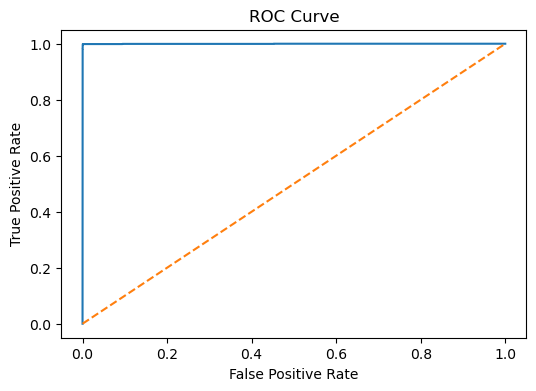

In [18]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

## 13. Precision-Recall Curve (Best for Imbalanced Data)
PR curve is more meaningful for fraud detection because fraud cases are rare.

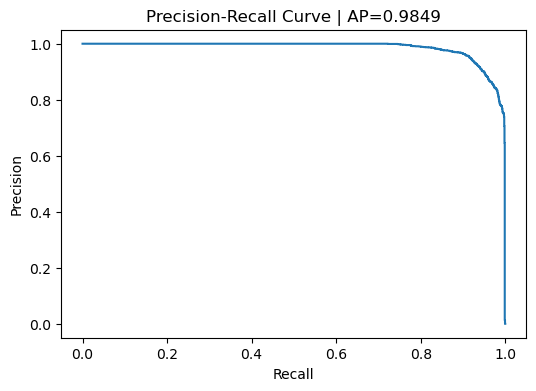

Average Precision (PR-AUC): 0.9849360965365678


In [19]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve | AP={ap:.4f}")
plt.show()

print("Average Precision (PR-AUC):", ap)

## 14. Threshold Tuning (Business Control)
Instead of using threshold=0.5, we can lower it to catch more fraud (higher recall).

In [20]:
threshold = 0.2
y_pred_custom = (y_prob >= threshold).astype(int)

print("Threshold:", threshold)
print(confusion_matrix(y_test, y_pred_custom))
print()
print(classification_report(y_test, y_pred_custom))

Threshold: 0.2
[[1270225     656]
 [      4    1639]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.71      1.00      0.83      1643

    accuracy                           1.00   1272524
   macro avg       0.86      1.00      0.92   1272524
weighted avg       1.00      1.00      1.00   1272524



## 15. Feature Importance (Key Fraud Drivers)
We extract top features that contribute most to fraud prediction.

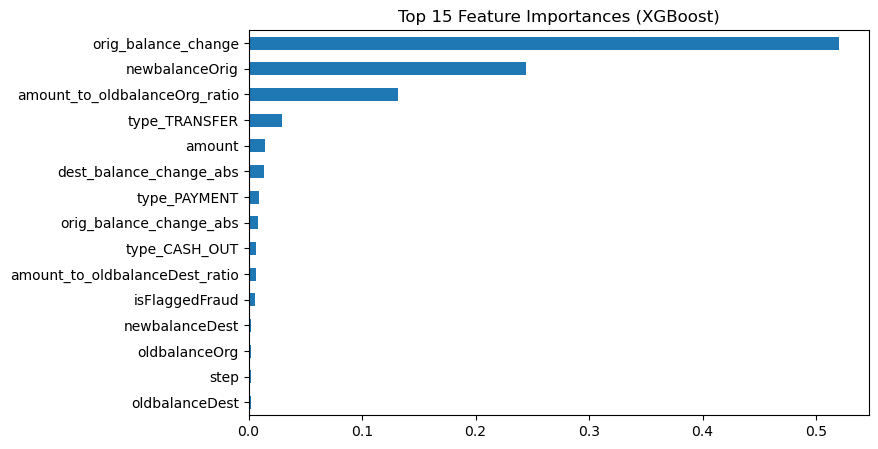

orig_balance_change               0.520229
newbalanceOrig                    0.244427
amount_to_oldbalanceOrg_ratio     0.131339
type_TRANSFER                     0.029073
amount                            0.014795
dest_balance_change_abs           0.013472
type_PAYMENT                      0.009552
orig_balance_change_abs           0.008085
type_CASH_OUT                     0.006697
amount_to_oldbalanceDest_ratio    0.006165
isFlaggedFraud                    0.005761
newbalanceDest                    0.002550
oldbalanceOrg                     0.002255
step                              0.001883
oldbalanceDest                    0.001708
dtype: float32

In [21]:
importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
top15 = importances.head(15)

plt.figure(figsize=(8,5))
top15.sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances (XGBoost)")
plt.show()

top15

## 16. Business Insights & Action Plan (Answers to Q5-Q8)
### Key factors predicting fraud (Q5)
- Transaction type (especially TRANSFER/CASH_OUT patterns)
- High transaction amount
- Large origin balance drop (orig_balance_change)
- Destination balance inconsistencies (dest_balance_change)

### Do factors make sense? (Q6)
Yes. Fraudsters often move money quickly using transfer/cash-out and show unusual balance changes.

### Prevention plan (Q7)
- Real-time fraud scoring API (block/hold high-risk transactions)
- OTP/MFA for high-risk transactions
- Velocity rules (many transactions in short time)
- Device & location anomaly detection
- Manual review queue for flagged transactions

### How to measure success (Q8)
- Track fraud loss reduction, recall/precision, false positives
- Monitor model drift monthly
- A/B test old vs new system for fraud loss & customer experience
